In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import numpy as np

from chime import calibration
from chime.calibration import load_CHIME_data
from chime import tv_channels
from chime import util

In [58]:
plot_dir = "/users/dbautist/CHIME_landing_directory/plots/calibration_comparison/"
util.check_dir(plot_dir)

In [59]:
all_days = glob.glob("/home/scratch/dbautist/CHIME_archive/202*")

for i in range(len(all_days)):
    all_days[i] = os.path.basename(all_days[i])

random_day = all_days[np.random.randint(0, len(all_days))]
print(f"random day, selecting: {random_day}")

random day, selecting: 2024_063


In [60]:
# test_day = "2025_003" # "2025_188" # "2026_044"  #"2025_071" #"2025_211"# "2026_183" #"2025_211" #"2025_211" #2025_001"
test_day = random_day
sample_file = f"/home/scratch/dbautist/CHIME_archive/{test_day}"
chime_grid, frequency, timestamps = load_CHIME_data(sample_file)

Text(0, 0.5, 'power [counts]')

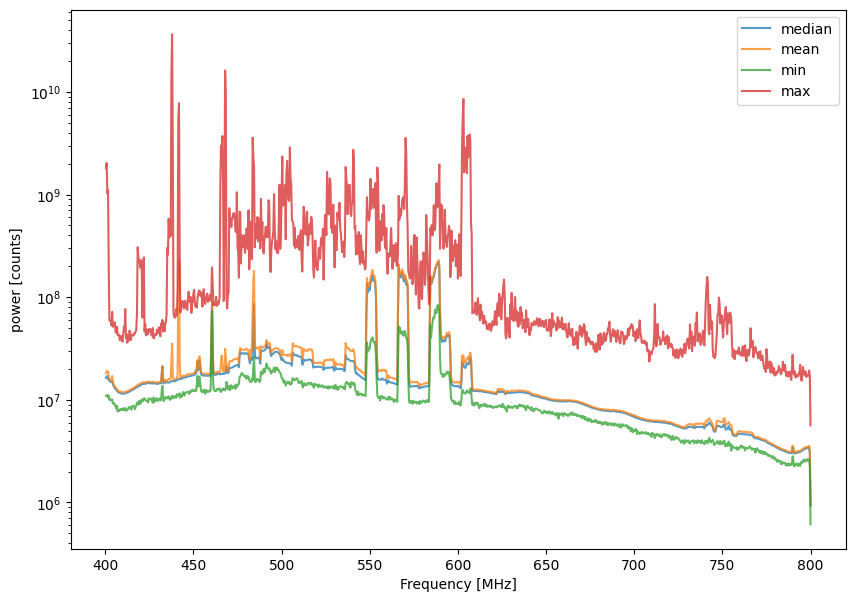

In [61]:
plt.figure(figsize=(10,7))
plt.plot(frequency, np.median(chime_grid, axis=0), label="median", alpha=0.75)
plt.plot(frequency, np.mean(chime_grid, axis=0), label="mean", alpha=0.75)
plt.plot(frequency, np.min(chime_grid, axis=0), label="min", alpha=0.75)
plt.plot(frequency, np.max(chime_grid, axis=0), label="max", alpha=0.75)
plt.legend()
plt.yscale("log")
plt.xlabel("Frequency [MHz]")
plt.ylabel("power [counts]")

In [62]:
def find_freq_indx(target_freq, frequency_axis):
    index = np.argmin(np.abs(frequency_axis - target_freq))
    return index

find_freq_indx(410, frequency)

25

(455.0, 465.0)

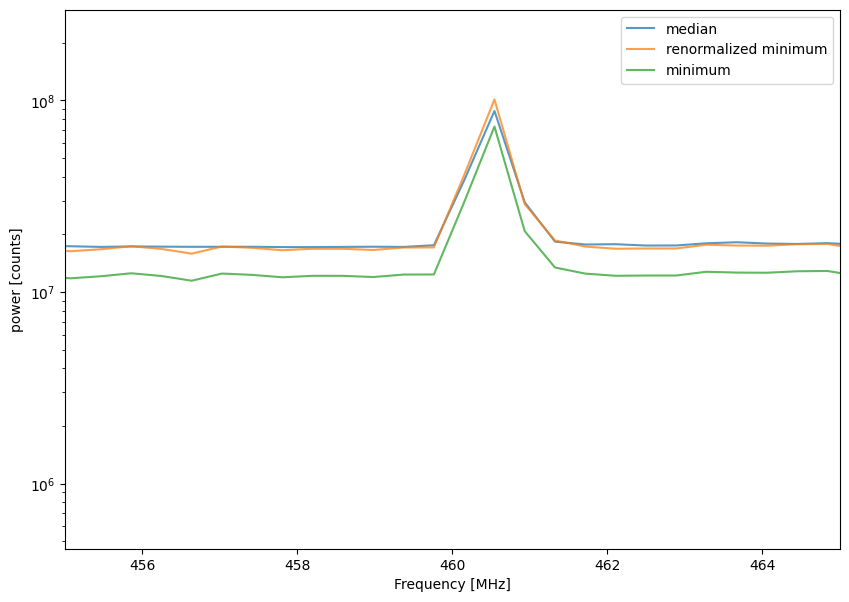

In [63]:
min_spect = np.min(chime_grid, axis=0)
med_spect = np.median(chime_grid, axis=0)

target_index = find_freq_indx(410, frequency)

norm_min = min_spect / min_spect[target_index]
norm_min_to_median = norm_min * med_spect[target_index]


plt.figure(figsize=(10,7))
plt.plot(frequency, med_spect, label="median", alpha=0.75)
plt.plot(frequency, norm_min_to_median, label="renormalized minimum", alpha=0.75)
plt.plot(frequency, min_spect, label="minimum", alpha=0.75)

plt.legend()
plt.yscale("log")
plt.xlabel("Frequency [MHz]")
plt.ylabel("power [counts]")
plt.xlim(455, 465)

(455.0, 465.0)

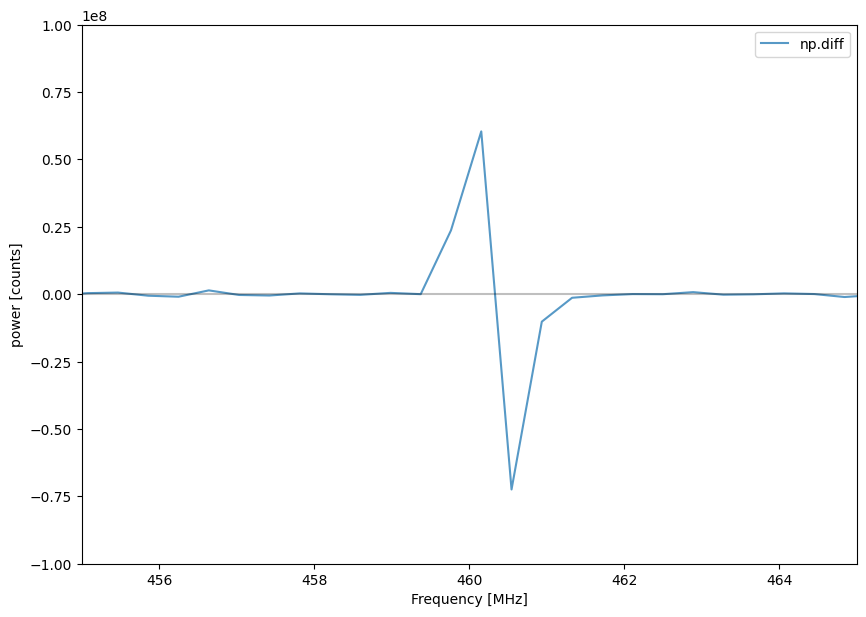

In [64]:
plt.figure(figsize=(10,7))
plt.plot(frequency[:-1], np.diff(norm_min_to_median), label="np.diff", alpha=0.75)
# plt.plot(frequency, norm_min_to_median, label="renormalized minimum", alpha=0.75)
# plt.plot(frequency, min_spect, label="minimum", alpha=0.75)

plt.legend()
# plt.yscale("log")
plt.xlabel("Frequency [MHz]")
plt.ylabel("power [counts]")
plt.ylim(-1e8,
          1e8)
plt.hlines(0, frequency.min(), frequency.max(), color="black", alpha=0.25)
plt.xlim(455, 465)

In [65]:
diff_spectrum = np.diff(norm_min_to_median)
diff_spect_roll=np.roll(diff_spectrum, 1)



In [66]:
def smooth_one_chan(spectrum):
    return

# borrowing some code from Pedro

In [67]:
from astropy.convolution import convolve, Box1DKernel, CustomKernel, Gaussian1DKernel
from scipy.special import iv


def box1d(data, width=64, **kwargs):
    """Smooth data using a box kernel.
    """

    kernel = Box1DKernel(width)
    return convolve(data, kernel, **kwargs)

def gauss1d(data, width=64, **kwargs):
    """Smooth data using a gaussian kernel
    """

    kernel = Gaussian1DKernel(width)
    return convolve(data, kernel, **kwargs)

def digital_filter(f_low, f_hgh, a, nterms):
    """Digital filter. Copied from IDL.

    Parameters
    ----------
    f_low : float
        The lower frequency of the filter as a fraction of the Nyquist frequency.
    f_hgh : float
        The upper frequency of the filter as a fraction of the Nyquist frequency.
    a : float
        The filter power relative to the Gibbs phenomenon wiggles in decibels. 50 is a good choice.
    nterms : int
        The number of terms used to construct the filter.
    
    Returns
    -------
    coefs : list
        Coefficients for the digital filter.
    """

    f_stop = 0.
    if f_hgh < f_low:
        f_stop = 1.

    if a < 20.:
        alpha = 0.
    elif a > 50:
        alpha = 0.1102 * (a - 8.7)
    else:
        alpha = 0.5842 * (a - 21.)**0.4 + 0.07886 * (a - 21.)

    x = np.arange(nterms, dtype=float)
    
    arg = (x + 1.)/nterms
    coef = iv(0, alpha*np.sqrt(1. - arg**2.)) / iv(0, alpha)
    t = (x + 1.)*np.pi
    coef = coef * (np.sin(t*f_hgh) - np.sin(t*f_low))/t
    coef = [coef[::-1], [f_hgh - f_low + f_stop], coef] #REPLICATE IT
    
    return [item for sublist in coef for item in sublist]

def highpass(data, **kwargs):
    """Highpass filter.
    Adapted from the GBT_RFI_pipeline:
    https://github.com/GreenBankObservatory/GBT_RFI_pipeline/blob/master/GBT_RFI_pipeline/scalUtils_wilsonedit.pro
    """

    kwargs.setdefault("normalize_kernel", False)

    ## added lines to correct for interpolation error
    ## Note: it does not flag the VEGAS spurs, so they 
    ##  will show up as RFI. They are quite obvious, because 
    ##  you only see them in one spectral window even when 
    ##  there's overlap between spectral windows.
    kwargs.setdefault("nan_treatment", "fill")
    kwargs.setdefault("fill_value", np.nan)
    kwargs.setdefault("preserve_nan", True)

    filter_coefs = digital_filter(0.1, 1, 200, 64)
    kernel = CustomKernel(filter_coefs)
    
    return convolve(data, kernel, **kwargs)

In [68]:
bad_channels = ["14", "15", "16",  "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "33", "34", "35", "36", "40", "41", "42", "57", "58", "59", "60", "61", "62", "63"]

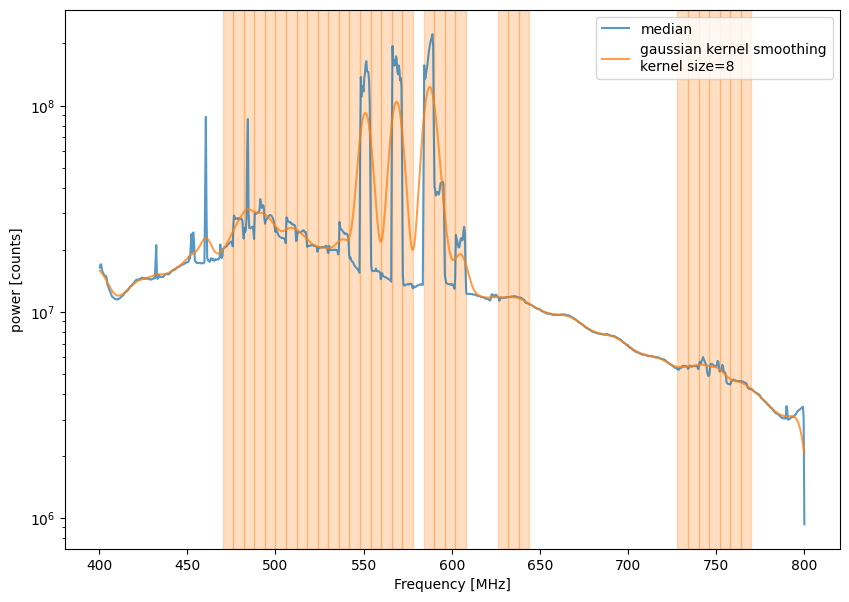

In [69]:
kernel_size = 8
kernel_type = "gauss"

med_smooth = gauss1d(med_spect, width=kernel_size, boundary="extend")
highpassed = highpass(med_spect)

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()
ax.plot(frequency, med_spect, label="median", alpha=0.75)
ax.plot(frequency, med_smooth, label=f"gaussian kernel smoothing\nkernel size={kernel_size}", alpha=0.75)
# ax.plot(frequency, highpassed, label="highpass filtered", alpha=0.75)
# ax.plot(frequency, np.mean(chime_grid, axis=0), label="mean", alpha=0.75)
# ax.plot(frequency, np.min(chime_grid, axis=0), label="min", alpha=0.75)
# ax.plot(frequency, np.max(chime_grid, axis=0), label="max", alpha=0.75)
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [counts]")

for chan in bad_channels:
    tv_channels.plot_channel(ax, chan)
# tv_channels.plot_channel(ax, "30")
# tv_channels.plot_channel(ax, "33")
# tv_channels.plot_channel(ax, "34")
# tv_channels.plot_channel(ax, "36")

plt.savefig(f"/users/dbautist/CHIME_landing_directory/plots/RFI_removal_test/{kernel_type}_kernel_size_{kernel_size}.png")
plt.show()
plt.close("all")

# Try masking the worst RFI channels

In [70]:
from scipy.interpolate import interp1d

In [71]:
channel_masks = []
padding = 0#0.390625

for bad_chan in bad_channels:
    this_mask = np.where((frequency >= (tv_channels.channel_dict[bad_chan]["lower"] - padding)) & (frequency <= (tv_channels.channel_dict[bad_chan]["upper"] + padding)))
    channel_masks.append(this_mask)

flag_mask = np.unique(np.hstack(channel_masks))
# flag_mask


# manually add other bad channel indices

In [72]:
find_freq_indx(548, frequency)
# frequency[168]

378

In [73]:
flag_mask = np.unique(np.hstack(channel_masks))
more_flags = [81, 82, 83, 152, 153, 154, 155, 156, 157, 158, 175, 176, 213, 214, 215, 216, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 193, 394, 440, 441, 470, 501, 502, 516]
more_flags = more_flags + list(range(567, 581))

In [74]:
flag_mask = np.hstack([flag_mask, more_flags])
# flag_mask

# keep specific indices

In [75]:
[300, 301, 302][np.argmin([med_spect[300], med_spect[301], med_spect[302]])]
[361, 362, 363][np.argmin([med_spect[361], med_spect[362], med_spect[363]])]
[192, 193, 194, 195][np.argmin([med_spect[192], med_spect[193], med_spect[194],  med_spect[195]])]

193

In [76]:
# harcoded indices to keep 
keep_these_channels = [[192, 193, 194, 195][np.argmin([med_spect[192], med_spect[193], med_spect[194],  med_spect[195]])],   #192, 
                       [209, 210, 211][np.argmin([med_spect[209], med_spect[210], med_spect[211]])], 
                       270, 
                      [300, 301, 302][np.argmin([med_spect[300], med_spect[301], med_spect[302]])],
                       331, 
                      [361, 362, 363][np.argmin([med_spect[361], med_spect[362], med_spect[363]])],
                      [377, 378, 397][np.argmin([med_spect[377], med_spect[378], med_spect[379]])]]

for item in keep_these_channels:
    flag_mask = np.delete(flag_mask, np.where(flag_mask == item))

# Use the rejection indices to generate mask to keep data

In [77]:
keep_mask = np.ones(med_spect.shape, dtype=bool)
keep_mask[flag_mask] = False

# frequency[keep_mask]

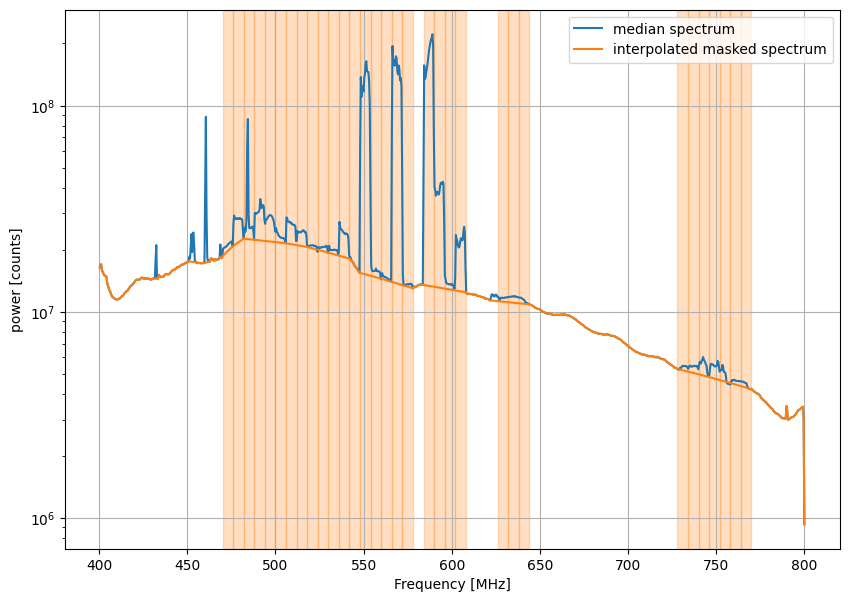

In [78]:
interp_spect = interp1d(frequency[keep_mask], med_spect[keep_mask])

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()

ax.plot(frequency, med_spect, label="median spectrum")
ax.plot(frequency, interp_spect(frequency), label="interpolated masked spectrum")

ax.legend()
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [counts]")

for chan in bad_channels:
    tv_channels.plot_channel(ax, chan)

# tv_channels.plot_channel(ax, "63", color="red")

# ax.vlines(548, 1e6, 1e8, colors="black")
ax.set_yscale("log")
ax.grid()
# ax.set_xlim(450, 500)


In [79]:
print(bad_channels)

['14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '33', '34', '35', '36', '40', '41', '42', '57', '58', '59', '60', '61', '62', '63']


# apply smoothing to the masked data

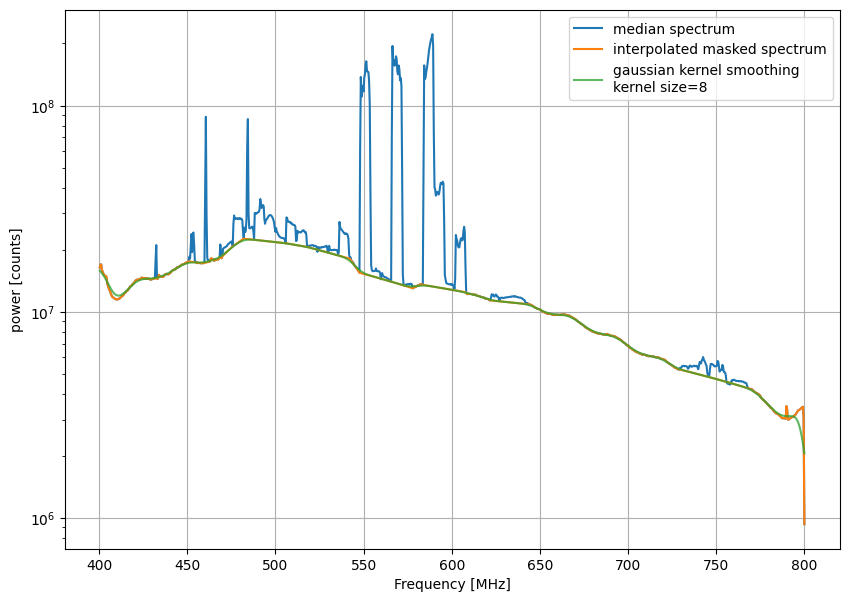

In [80]:
kernel_type = "gaussian"
kernel_size = 8
smoothed_interp = gauss1d(interp_spect(frequency), width=kernel_size, boundary="extend")

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()

ax.plot(frequency, med_spect, label="median spectrum")
ax.plot(frequency, interp_spect(frequency), label="interpolated masked spectrum")
ax.plot(frequency, smoothed_interp, label=f"gaussian kernel smoothing\nkernel size={kernel_size}", alpha=0.75)

ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [counts]")

# for chan in bad_channels:
#     tv_channels.plot_channel(ax, chan)
# ax.set_xlim(400, 420)
ax.grid()
plt.savefig(f"{plot_dir}/spectrum_mask.png", transparent=False, bbox_inches="tight")
plt.show()
plt.close()

# recalibrating with interpolated and smoothed spectrum

In [81]:
def usual_calibration(on, off, tsys):
    """
    Equation for the flux of a source from and on/off observation
    pulled directly from Single-Dish Radio Astronomy: Techniques and Applications, 
    Part 3: Calibration and Data Reduction, Single-Dish Calibration Techniques at Radio Wavelengths
    Section 3: System Temperature
    Equation 20:

    T_{source} = [ (T_ON - T_OFF) / T_OFF]

    Arguments:
    ---------------
    on : numpy.ndarray
        Spectrum with the source in the beam. The ON observation
    off : numpy.ndarray
        Spectrum with source NOT in the beam. The OFF observation
    tsys : float
        The known system temperature when observing blank sky

    Returns:
    ---------------
    tsource : numpy.ndarray
        The calibrated spectrum with units of T_sys
    """
    return (on - off) / off * tsys

def tsys(off_cal, on_cal, t_cal):
    """
    Equation for the flux of a source from and on/off observation
    pulled directly from Single-Dish Radio Astronomy: Techniques and Applications, 
    Part 3: Calibration and Data Reduction, Single-Dish Calibration Techniques at Radio Wavelengths
    Section 3: System Temperature
    Equation 22:

    T_{sys} = [ OFFCAL / (ONCAL - OFFCAL) ] * T_cal

    Arguments:
    ---------------
    on_cal : numpy.ndarray
        Spectrum with the known calibrator on. The ONCAL observation
    off_cal : numpy.ndarray
        Spectrum with known calibrator off. The OFFCAL observation
    t_cal : float
        The known system temperature contribution of the calibrator 

    Returns:
    ---------------
    tsource : numpy.ndarray
        The system temperature in units of T_cal
    """
    return off_cal / (on_cal - off_cal) * t_cal

In [82]:
df = pd.read_csv("/users/dbautist/CHIME_landing_directory/calibration_log.csv")
df = df[df["success"] == True]
df

,date,target_freq,target_flux,height,center,width,baseline,sun_projection,success
0,2024_056,410,490000.0,2.639661e+07,1817.148024,12.962662,1.287077e+07,0.515785,True
1,2024_057,410,490000.0,1.872937e+07,1819.617887,12.915378,1.275228e+07,0.521489,True
2,2024_058,410,490000.0,1.724214e+07,1819.617003,13.076639,1.239522e+07,0.527059,True
3,2024_059,410,490000.0,2.869793e+07,1817.565499,12.814123,1.232037e+07,0.532711,True
4,2024_060,410,490000.0,2.291275e+07,1818.107757,13.743389,1.226643e+07,0.538172,True
...,...,...,...,...,...,...,...,...,...
865,2026_197,410,490000.0,7.464273e+07,1921.812567,10.737684,1.135171e+07,0.877680,True
866,2026_196,410,490000.0,6.023388e+07,1921.317319,12.103693,1.131687e+07,0.879042,True
867,2026_198,410,490000.0,7.056650e+07,1922.415645,11.040752,1.137613e+07,0.876263,True
868,2026_199,410,490000.0,7.630899e+07,1922.045400,10.942536,1.152046e+07,0.874758,True


In [83]:
this_day_df = df[df["date"] == test_day]
this_day_df

,date,target_freq,target_flux,height,center,width,baseline,sun_projection,success
7,2024_063,410,490000.0,1.964314e+07,1817.154275,14.585245,1.267607e+07,0.554942,True


In [84]:
tsys = this_day_df["baseline"].values / this_day_df["height"].values * this_day_df["target_flux"].values # 1.025398e+07 / (8.881501e+07	) * 490000.0
tsys

array([316205.86062199])

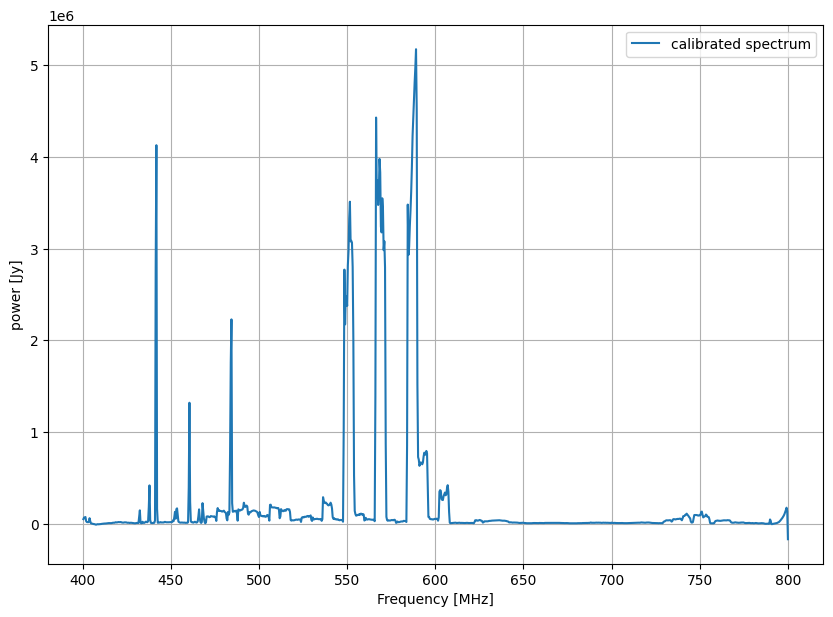

In [85]:
calibrated_spectrum = usual_calibration(np.mean(chime_grid, axis=0), smoothed_interp, tsys )

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()

ax.plot(frequency, calibrated_spectrum, label="calibrated spectrum")

ax.legend()
# ax.set_yscale("log")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [Jy]")
# ax.hlines(0, frequency.min(), frequency.max(), color="black")
plt.savefig(f"{plot_dir}/calibrated_spectrum.png", bbox_inches="tight", transparent=False)
ax.grid()

In [86]:
tsys = df["baseline"] / (df["height"]) * df["target_flux"]
tsys

0      238919.877331
1      333626.783941
2      352256.765194
3      210362.868878
4      262323.464526
           ...      
865     74519.463384
866     92062.242820
867     78993.643654
868     73975.863104
869     65638.425866
Length: 835, dtype: float64

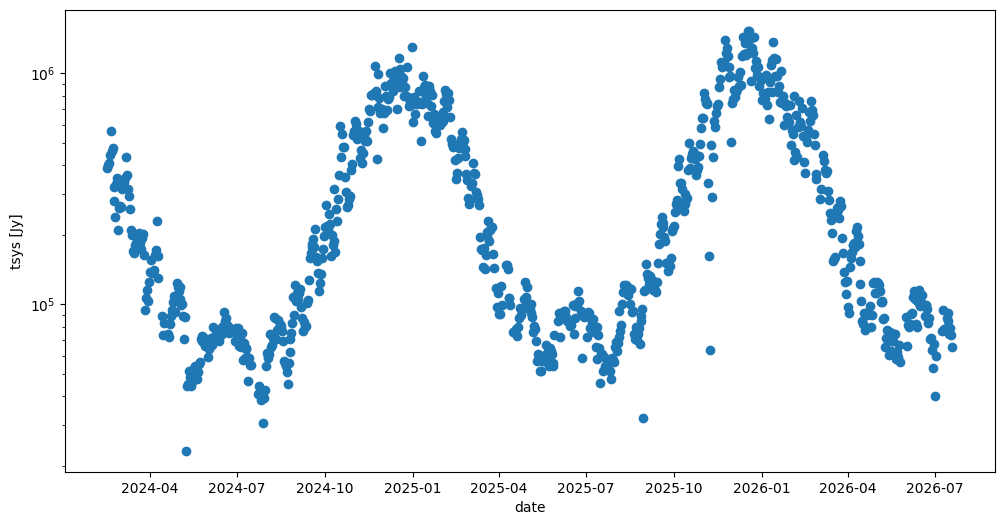

In [87]:
days = []
for i in range(len(df)):
    days.append(util.yyyy_ddd_to_datetime(df.iloc[i]["date"]))

plt.figure(figsize=(12,6))
plt.scatter(days, tsys)
plt.xlabel("date")
plt.ylabel("tsys [Jy]")
# plt.ylim(0, 5e6)
plt.yscale("log")

# Waterfall of the raw data

In [88]:
from datetime import datetime, timezone

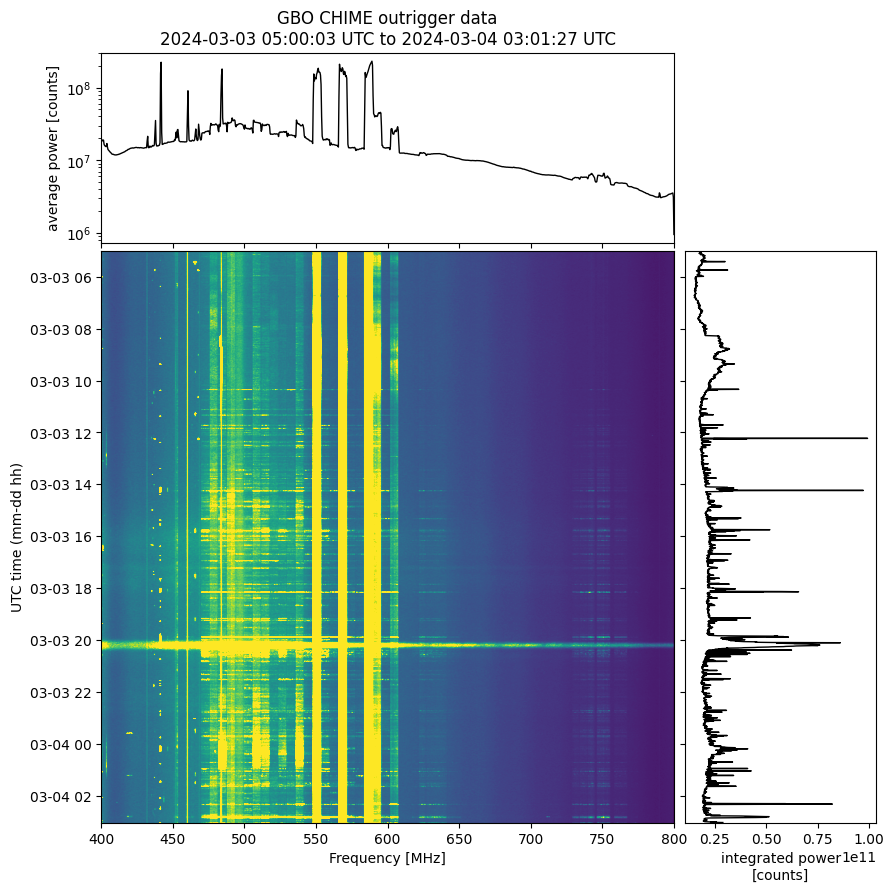

In [89]:
# CHIME_data, frequency, timestamps = calibration.load_CHIME_data(os.path.dirname(data_path))
calibrated = False
time_zone = timezone.utc

if calibrated:
    unit = "Jy"
    CHIME_data = calibration.calibration(data_path)
    vmin=1e4
    vmax=7e5
else:
    unit = "counts"
    vmin=0
    vmax=4e7
start_time = timestamps[0]
end_time = timestamps[-1]

time_series = np.sum(chime_grid, axis=1)
average_spectrum = np.mean(chime_grid, axis=0)

extent = [np.round(np.min(frequency)), np.round(np.max(frequency)), max(timestamps), min(timestamps)] 
fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(2,2, hspace=0.02, wspace=0.03, width_ratios=[3,1], height_ratios=[1,3])
(ax1, ax2), (ax3, ax4) = gs.subplots(sharex="col", sharey="row")
ax1.set_title(f"GBO CHIME outrigger data\n{start_time.astimezone(time_zone).strftime('%Y-%m-%d %H:%M:%S %Z')} to {end_time.astimezone(time_zone).strftime('%Y-%m-%d %H:%M:%S %Z')}")
ax1.semilogy(frequency, average_spectrum, color="black", linewidth=1)
ax1.set_ylabel(f"average power [{unit}]")
ax2.set_visible(not ax2)
ax3.imshow(chime_grid, aspect="auto", extent=extent, vmin=vmin, vmax=vmax)
ax3.set_xlabel("Frequency [MHz]")
ax3.set_ylabel(f"{start_time.astimezone(time_zone).strftime('%Z')} time (mm-dd hh)")
ax4.plot(time_series, timestamps, color="black", linewidth=1)
ax4.set_xlabel(f"integrated power\n[{unit}]")

plt.savefig(f"{plot_dir}/raw_data.png", bbox_inches="tight", transparent=False)
plt.show()
plt.close()

# Applying the calibration to a full day of data and generating a waterfall

In [90]:
CHIME_data = usual_calibration(chime_grid, smoothed_interp, 56572.06861961)
vmin = 0
vmax = 200000
time_zone = timezone.utc

unit = "Jy"

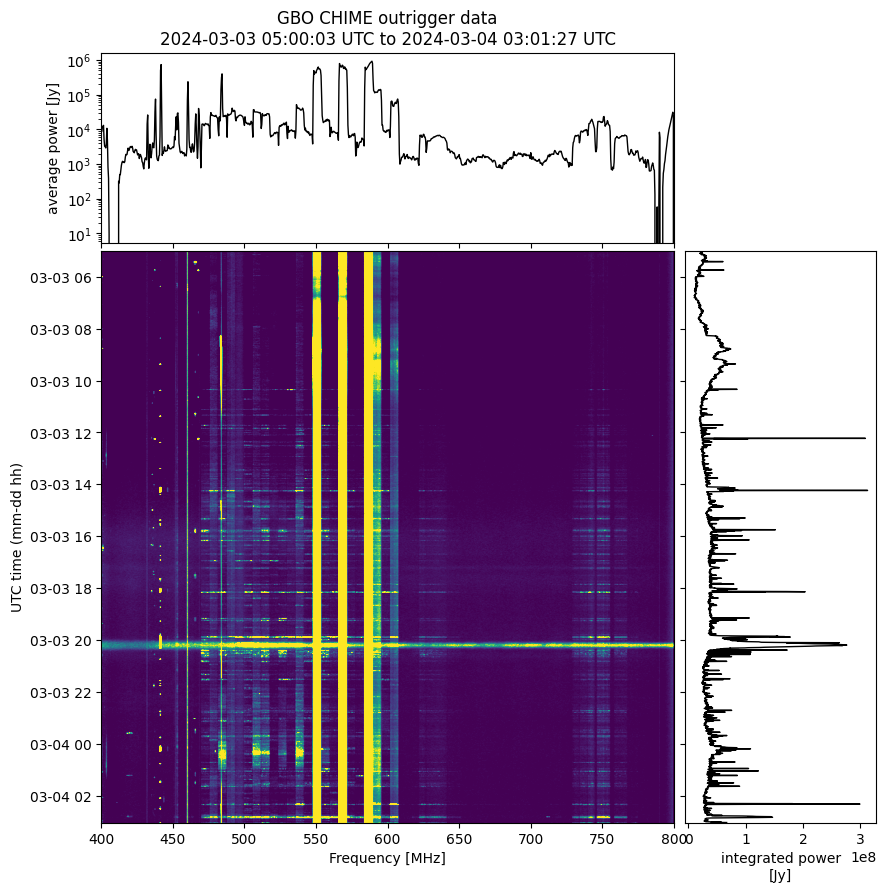

In [91]:
start_time = timestamps[0]
end_time = timestamps[-1]

time_series = np.sum(CHIME_data, axis=1)
average_spectrum = np.mean(CHIME_data, axis=0)

extent = [np.round(np.min(frequency)), np.round(np.max(frequency)), max(timestamps), min(timestamps)] 
fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(2,2, hspace=0.02, wspace=0.03, width_ratios=[3,1], height_ratios=[1,3])
(ax1, ax2), (ax3, ax4) = gs.subplots(sharex="col", sharey="row")
ax1.set_title(f"GBO CHIME outrigger data\n{start_time.astimezone(time_zone).strftime('%Y-%m-%d %H:%M:%S %Z')} to {end_time.astimezone(time_zone).strftime('%Y-%m-%d %H:%M:%S %Z')}")
ax1.plot(frequency, average_spectrum, color="black", linewidth=1)
ax1.set_ylabel(f"average power [{unit}]")
ax2.set_visible(not ax2)
ax3.imshow(CHIME_data, aspect="auto", extent=extent, vmin=vmin, vmax=vmax)
ax3.set_xlabel("Frequency [MHz]")
ax3.set_ylabel(f"{start_time.astimezone(time_zone).strftime('%Z')} time (mm-dd hh)")
ax4.plot(time_series, timestamps, color="black", linewidth=1)
ax4.set_xlabel(f"integrated power\n[{unit}]")

# ax1.set_ylim(-100000, 5e6)
ax1.set_yscale("log")

plt.savefig(f"{plot_dir}/new_calibration.png", bbox_inches="tight", transparent=False)
plt.show()
plt.close()

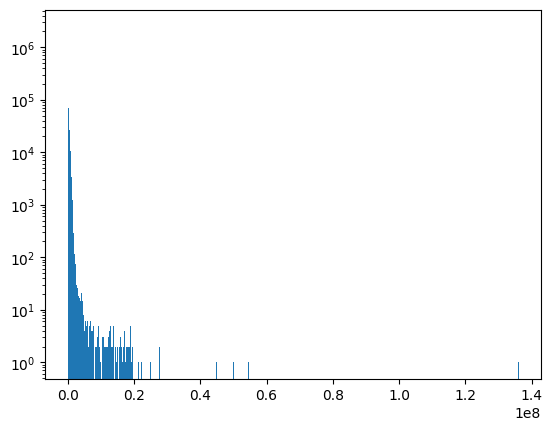

In [92]:
plt.figure()
_=plt.hist(np.hstack(CHIME_data), bins=1000)
plt.yscale("log")